# 딥러닝
- 사람의 뇌 신경망을 흉내 내어 만든 **인공 신경망(Neural Network)** 을 사용하는 기술입니다.

데이터를 입력하면 여러 층(Layer)을 통과하면서 스스로 데이터의 특징을 찾아내고 학습합니다. 컴퓨터가 마치 사람처럼 "이 사진은 고양이네!", "이 문장은 슬픈 감정이네?"라고 스스로 판단할 수 있게 만드는 과정이라고 보시면 됩니다.

## 머신러닝 vs 딥러닝 : 차이점
가장 큰 차이는 **'사람이 개입하느냐, 아니냐'** 에 있습니다.

- 머신러닝 (기계 학습): 컴퓨터에게 "고양이는 귀가 뾰족하고 수염이 있어"라고 사람이 특징(Feature)을 직접 알려줘야 합니다. 기계는 사람이 알려준 규칙을 바탕으로 정답을 찾습니다.

- 딥러닝 (심층 학습): 사람이 특징을 알려줄 필요가 없습니다. 수만 장의 사진을 던져주면 딥러닝 모델이 스스로 "아, 고양이는 이런 특징이 있구나"를 찾아냅니다.

## 딥러닝은 주로 데이터가 복잡하고 양이 많을 때 빛을 발합니다.

컴퓨터 비전: 사진이나 영상 속 물체 인식 (예: 자율주행 자동차, 얼굴 인식 잠금 해제)

자연어 처리 (NLP): 사람의 말을 이해하고 생성 (예: ChatGPT, 번역기, 챗봇)

음성 인식: 목소리를 텍스트로 변환 (예: 시리, 빅스비)

추천 시스템: 내가 좋아할 만한 영상이나 상품 추천 (예: 유튜브 알고리즘, 넷플릭스)

# 딥러닝 라이브러리 2가지
## 텐서플로우(google) - 산업용
* 이미지 관련 라이브러리
* keras를 이용해 코딩이 쉬움
* 순차적, 함수적, 클래스

## 파이토치(meta) - 연구용
* 자연어 관련 라이브러리
* 허깅페이스, 랭체인
* 클래스
* 학습의 모든 과정을 커스텀화 할 수 있음

In [1]:
# 딥러닝을 하기 위해 전용 도구함(텐서플로우)을 여는 과정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [2]:
data = pd.read_csv("https://raw.githubusercontent.com/haram4th/ablearn/main/Taitanic_train.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [4]:
data = data[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Embarked']]
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,male,22.0,1,0,S
1,1,1,female,38.0,1,0,C
2,1,3,female,26.0,0,0,S
3,1,1,female,35.0,1,0,S
4,0,3,male,35.0,0,0,S


In [5]:
# 두 컬럼 family로 합치기
data['family'] = data['SibSp'] + data['Parch']
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked,family
0,0,3,male,22.0,1,0,S,1
1,1,1,female,38.0,1,0,C,1
2,1,3,female,26.0,0,0,S,0
3,1,1,female,35.0,1,0,S,1
4,0,3,male,35.0,0,0,S,0


In [7]:
data = data.drop(['SibSp', 'Parch'], axis=1)
data # 필요한 컬럼들만 남음

,Survived,Pclass,Sex,Age,Embarked,family
0,0,3,male,22.0,S,1
1,1,1,female,38.0,C,1
2,1,3,female,26.0,S,0
3,1,1,female,35.0,S,1
4,0,3,male,35.0,S,0
...,...,...,...,...,...,...
886,0,2,male,27.0,S,0
887,1,1,female,19.0,S,0
888,0,3,female,NaN,S,3
889,1,1,male,26.0,C,0


- 특성(X)과 타겟(y) 분리

X (특성): 정답을 맞히기 위해 필요한 정보들 (예: 공부 시간, 수면 시간)

y (타겟): 우리가 맞히려는 정답 (예: 시험 합격 여부)

비유: 문제지(X)와 해답지(y)를 분리하는 과정입니다.

In [8]:
X = data.drop('Survived', axis=1)
y = data['Survived']

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [11]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 623 entries, 748 to 136
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    623 non-null    int64  
 1   Sex       623 non-null    str    
 2   Age       504 non-null    float64
 3   Embarked  621 non-null    str    
 4   family    623 non-null    int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 29.2 KB


# 딥러닝시에도 데이터 스케일을 맞춰 주어야 함


* MinMaxScaler를 주로 사용, StandardScaler도 사용, 이상값이 많은 경우 RobustScaler사용
* 이진분류: MinMax
* 연속값예측: Standard

### 데이터 스케일링 (Scaling)

코드: StandardScaler() 또는 MinMaxScaler()

설명: 데이터의 단위(범위)를 맞춥니다.

예를 들어, '나이(0-100)'와 '연봉(0-수억)'은 숫자의 크기가 너무 다릅니다. 이를 0-1 사이의 값으로 압축하거나 평균이 0이 되도록 조정합니다.

중요: 스케일링을 안 하면 숫자가 큰 데이터에만 모델이 과하게 반응할 수 있습니다. 딥러닝 성능 향상을 위해 꼭 필요합니다.

In [12]:
X_train.columns

Index(['Pclass', 'Sex', 'Age', 'Embarked', 'family'], dtype='str')

In [13]:
num_cols = ['Age', 'family']
cat_cols = ['Pclass', 'Sex', 'Embarked']

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [16]:
num_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='mean')),
    ('mmx', MinMaxScaler())
])

cat_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

prep = ColumnTransformer(transformers=[
    ('num_cols', num_pipe, num_cols),
    ('cat_cols', cat_pipe, cat_cols)
], remainder='drop')

X_train_ppd = prep.fit_transform(X_train)
X_test_ppd = prep.transform(X_test)

## 여기까지 전처리 함

데이터 탐색 (EDA) → 결측치 처리 (Imputation) → 인코딩 (Encoding)(글자를 숫자로 변경) → 문제X와 정답y 분리 → 데이터셋 분할(Train/Test Split)(공부용/시험용 분리) → 피처 스케일링 (Feature Scaling)(숫자 단위 맞추기)

# 텐서플로우(TensorFlow)라는 도구를 사용해서 딥러닝 모델을 설계하는 3가지 스타일(방법론)

### 1. Sequential API (순차적 방식)
특징: 가장 쉽고 간결합니다. 층(Layer)을 한 줄로 차례차례 쌓기만 하면 됩니다.

비유: 레고 블록을 수직으로 하나씩 쌓는 것과 같습니다.

언제 쓰나?: 입력이 하나고 출력이 하나인 단순한 구조의 모델을 만들 때 가장 많이 씁니다. 입문 단계에서 배우는 대부분의 모델이 이 방식입니다.

### 2. Functional API (함수형 방식)
특징: Sequential보다 자유롭습니다. 각 층을 함수처럼 정의해서 서로 연결합니다.

비유: 여러 갈래의 길이 합쳐지거나 나눠지는 복잡한 도로망을 설계하는 것과 같습니다.

언제 쓰나?: 데이터 입구가 여러 개거나(예: 이미지와 텍스트를 동시에 입력), 정답지가 여러 개인 복잡한 모델을 만들 때 필수적입니다.

### 3. Subclassing API (클래스 방식)
특징: 파이썬의 class 문법을 사용합니다. 모델의 모든 동작을 직접 코딩해야 하므로 가장 어렵지만, 제한이 전혀 없습니다.

비유: 기성품 가구를 사는 게 아니라, 나무를 깎고 조립해서 세상에 하나뿐인 가구를 만드는 목수와 같습니다.

언제 쓰나?: 기존에 없던 새로운 방식의 인공지능 알고리즘을 연구하거나, 논문에 나온 복잡한 모델을 직접 구현할 때 사용합니다.

# 1. Sequential API
## -> 전처리된 데이터를 이용한 가장 직관적인 모델 생성 방식

# Tensorflow Sequential API를 사용한 순차적 모델 생성 및 분석

* Sequential: 인공신경망을 순차적으로 작성할 때 사용
* Dense: 층, 레이어 , 입력층, 은닉층, 출력층


In [18]:
import keras
import tensorflow as tf
from keras import Input
from keras.models import Sequential
from keras.layers import Dense

* 입력층은 반드시 독립변수의수(input_dim)를 정확히 지정
* 신경망 모델의 은닉층은 2~3개 정도로 한다.
* Dense의 노드수는 2의 배수의 지정 2 4 8 16 256
* Dense의 노드는 큰 수에서 작은 수로 줄여나간다.
* 은닉층의 활성화 함수: Relu
* 출력층은 이진분류일 경우 sigmoid, 다중분류일 경우 softmax
* 회귀분석일 경우(종속변수가 연속형(수치형)인 경우) 출력층에 활성화 함수 없이 노드를 1로 지정

In [24]:
# 독립변수 수 계산
X_train_ppd.shape[1]

7

In [23]:
# # 옛날 버전 코드
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense

# model = Sequential()

# model.add(Dense(64,
#                 activation='relu',
#                 input_dim=X_train_ppd.shape[1]))  # 입력층

# model.add(Dense(32, activation='relu'))  # 은닉층
# model.add(Dense(16, activation='relu'))  # 은닉층

# model.add(Dense(1, activation='sigmoid'))  # 출력층

In [42]:
# keras 3.0 기준 신경망 모델 정의
# 입력층 - 은닉층 - 은닉층 .. - 출력층
model = Sequential()
model.add(Input(shape=(X_train_ppd.shape[1],)))  # 입력층
model.add(Dense(64, activation='relu')) # 은닉층
model.add(Dense(32, activation='relu')) # 은닉층
model.add(Dense(16, activation='relu')) # 은닉층
model.add(Dense(1, activation='sigmoid')) # 출력층, 이진분류이므로 sigmoid

In [43]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

#  모델의 파라미터 세팅 
# model.compile()
### 모델 보고 어떤 지표 선택해야할 지 잘 판단하기!!

* loss: 오차 계산 지표
  * 이진분류: binary_crossentropy
  * 다중분류: categorical_crossentropy - y가 one-hot encoding
  * 다중분류2: sparse_categorical_crossentropy - y가 label encoding
  * 연속형데이터(회귀분석): mse
* optimizer: learning_rate
  * adam을 가장 많이 사용
* metrics: 평가지표 accuracy

In [44]:
# pd.get_dummies(y_train)

In [45]:
# y_train

In [46]:
# 모델의 파라미터 세팅
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])


# 모델 훈련 model.fit(X_train, y_train)
- 머신러닝 : 모델 훈련 1번만 함 / 딥러닝 : 모델 훈련 여러 번 함

* epochs: 전체 데이터를 한 번 훈련하는 주기, 10-100 사이
* batch_size: 전체 데이터를 쪼개서 훈련, 데이터의 묶음, 메모리에 맞춰서 크기 조절(2의 배수) 32, 64로 쪼개서 넣는 것 추천
* validation_data: 검증 데이터로 모델 검증 실시

In [47]:
history = model.fit(X_train_ppd, y_train, epochs=300, batch_size=16,
                   validation_data=(X_test_ppd, y_test))

Epoch 1/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.6196 - loss: 0.6107 - val_accuracy: 0.6157 - val_loss: 0.5720
Epoch 2/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7352 - loss: 0.5501 - val_accuracy: 0.8172 - val_loss: 0.5381
Epoch 3/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7801 - loss: 0.5272 - val_accuracy: 0.7761 - val_loss: 0.5343
Epoch 4/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8042 - loss: 0.5080 - val_accuracy: 0.8172 - val_loss: 0.5008
Epoch 5/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8122 - loss: 0.4909 - val_accuracy: 0.8172 - val_loss: 0.4818
Epoch 6/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8090 - loss: 0.4720 - val_accuracy: 0.8172 - val_loss: 0.4655
Epoch 7/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8026 - loss: 0.4662 - val_accuracy: 0.8172 - val_loss: 0.4569
Epoch 8/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8090 - loss: 0.4524 - val_accuracy: 0.8172 - 

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8266 - loss: 0.3874 - val_accuracy: 0.7873 - val_loss: 0.4261
Epoch 102/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8459 - loss: 0.3825 - val_accuracy: 0.8097 - val_loss: 0.4195
Epoch 103/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8250 - loss: 0.3869 - val_accuracy: 0.7873 - val_loss: 0.4224
Epoch 104/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8315 - loss: 0.3789 - val_accuracy: 0.7724 - val_loss: 0.4448
Epoch 105/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8347 - loss: 0.3858 - val_accuracy: 0.7985 - val_loss: 0.4230
Epoch 106/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8331 - loss: 0.3841 - val_accuracy: 0.7985 - val_loss: 0.4237
Epoch 107/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8379 - loss: 0.3804 - val_accuracy: 0.7910 - val_loss: 0.4257
Epoch 108/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8411 - loss: 0.3817 - val_accuracy: 0.8022 -

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8459 - loss: 0.3560 - val_accuracy: 0.8060 - val_loss: 0.4517
Epoch 202/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8555 - loss: 0.3545 - val_accuracy: 0.8134 - val_loss: 0.4535
Epoch 203/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8523 - loss: 0.3558 - val_accuracy: 0.7948 - val_loss: 0.4691
Epoch 204/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8523 - loss: 0.3554 - val_accuracy: 0.8172 - val_loss: 0.4564
Epoch 205/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8507 - loss: 0.3572 - val_accuracy: 0.8134 - val_loss: 0.4579
Epoch 206/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8539 - loss: 0.3566 - val_accuracy: 0.8060 - val_loss: 0.4529
Epoch 207/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8459 - loss: 0.3541 - val_accuracy: 0.8172 - val_loss: 0.4557
Epoch 208/300
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8475 - loss: 0.3547 - val_accuracy: 0.8097 -

# 딥러닝 모델 성능 평가
* 딥러닝에서 모델의 성능을 평가하는 지표는 loss
* 보통 loss가 낮으면 accuracy가 올라가지만 비례하지 않을 때도 있음.
* accuracy와 loss 간의 차이가 있을 때 loss가 낮은 모델이 우수한 모델

In [48]:
pd.DataFrame(history.history)

,accuracy,loss,val_accuracy,val_loss
0,0.619583,0.610732,0.615672,0.571965
1,0.735152,0.550076,0.817164,0.538141
2,0.780096,0.527195,0.776119,0.534253
3,0.804173,0.507981,0.817164,0.500776
4,0.812199,0.490853,0.817164,0.481788
...,...,...,...,...
295,0.853933,0.337475,0.817164,0.501347
296,0.857143,0.335477,0.764925,0.535807
297,0.852327,0.337395,0.791045,0.540767
298,0.858748,0.332140,0.802239,0.523978


# 훈련 결과 시각화

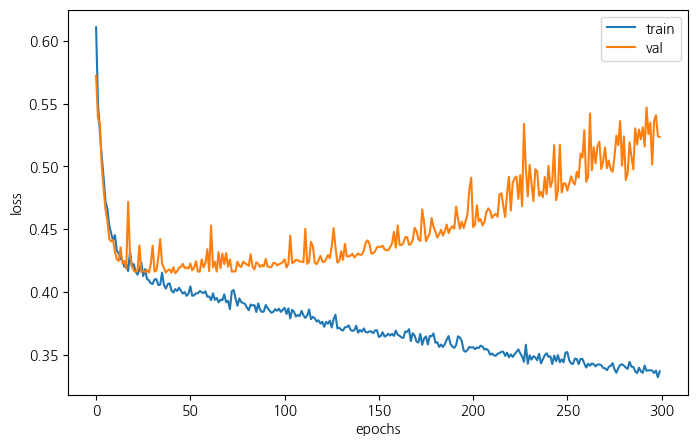

In [49]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

## 로스가 가장 낮은 부분 찾아서 그 모델 사용

# 모델의 예측 값 출력

In [50]:
pred = model.predict(X_test_ppd)
pred

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step


array([[2.59126872e-01],
       [9.14621428e-02],
       [7.57230744e-02],
       [1.17643557e-01],
       [3.88077088e-02],
       [4.06131536e-01],
       [8.62915292e-02],
       [9.99991417e-01],
       [1.29375488e-01],
       [9.99604583e-01],
       [7.73615539e-01],
       [9.99840498e-01],
       [2.77081937e-01],
       [2.60951757e-01],
       [9.81549680e-01],
       [6.27485037e-01],
       [7.57230744e-02],
       [3.68044347e-01],
       [9.58873630e-01],
       [2.15157479e-01],
       [6.74261572e-03],
       [6.55452022e-03],
       [4.43330258e-01],
       [1.17643557e-01],
       [6.35405421e-01],
       [4.93404418e-02],
       [9.99707997e-01],
       [2.39409193e-01],
       [1.88608223e-03],
       [2.42354069e-02],
       [8.58336389e-01],
       [9.63939130e-01],
       [7.57230744e-02],
       [6.85709834e-01],
       [9.98494983e-01],
       [3.93792003e-01],
       [7.57230744e-02],
       [4.16140584e-03],
       [7.57230744e-02],
       [2.68407762e-01],


In [53]:
result = pd.DataFrame(dict(y_test=y_test, pred=pred[:,0]))
result['pred'] =  result['pred'].apply(lambda x: 1 if x >= 0.5 else 0)
result

,y_test,pred
625,0,0
566,0,0
459,0,0
804,1,0
338,1,0
...,...,...
184,1,1
607,1,0
624,0,0
103,0,0


# 2. Functional API를 이용한 함수형 모델
* Sequential API는 단순히 층을 여러 개 쌓는 형태라 복잡한 모델 생성에 한계가 있음.
* Functional  API는 입력층과 출력층을 사용자가 직접 정의 가능
* 다중입력(Multi-input), 다중출력(Multi-output)등 복잡한 모델을 정의 할 수 있음.
* Input(shape=(독립변수 수))로 입력층 정의
* 이전 층을 다음 층의 입력으로 사용
* model()에 입력과 출력을 정의

In [54]:
from keras.layers import Input, Dense
from keras.models import Model

In [ ]:
# # 신경망 모델 정의 kearas 3.0, tensorflow 2.19 기준
# model = Sequential()
# model.add(Input(shape=(X_train_ppd.shape[1],))) # 입력층
# model.add(Dense(64, activation='relu')) # 은닉층
# model.add(Dense(32, activation='relu')) # 은닉층
# model.add(Dense(16, activation='relu')) # 은닉층
# model.add(Dense(1, activation='sigmoid')) # 출력층, 이진분류이므로 sigmoid

In [55]:
# 입력층
inputs = Input(shape=(X_test_ppd.shape[1],))

# 은닉층
x = Dense(64, activation='relu')(inputs)
x = Dense(32, activation='relu')(x)
x = Dense(16, activation='relu')(x)

# 출력층
outputs = Dense(1, activation='sigmoid')(x)

# 모델 정의
model = Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
from sklearn.metrics import classification_report

Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.6164 - loss: 0.6349 - val_accuracy: 0.6343 - val_loss: 0.5938
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7416 - loss: 0.5561 - val_accuracy: 0.8097 - val_loss: 0.5237
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8042 - loss: 0.5067 - val_accuracy: 0.8097 - val_loss: 0.4906
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8042 - loss: 0.4786 - val_accuracy: 0.7948 - val_loss: 0.4704
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8074 - loss: 0.4621 - val_accuracy: 0.7948 - val_loss: 0.4583
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8058 - loss: 0.4517 - val_accuracy: 0.8172 - val_loss: 0.4442
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7897 - loss: 0.4498 - val_accuracy: 0.8172 - val_loss: 0.4364
Epoch 8/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8074 - loss: 0.4430 - val_accuracy: 0.7948 - 

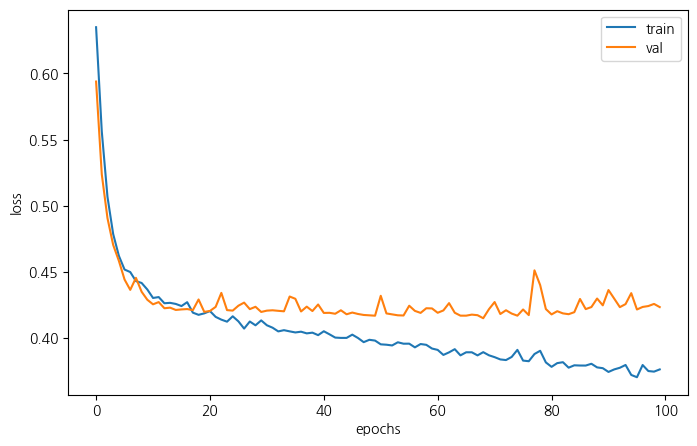

              precision    recall  f1-score   support

           0       0.81      0.93      0.86       165
           1       0.85      0.64      0.73       103

    accuracy                           0.82       268
   macro avg       0.83      0.78      0.80       268
weighted avg       0.82      0.82      0.81       268



In [57]:
# 모델의 파라미터 세팅
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X_train_ppd, y_train, epochs=100, batch_size=16,
                   validation_data=(X_test_ppd, y_test))
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()
pred = model.predict(X_test_ppd)
pred
result = pd.DataFrame(dict(y_test=y_test, pred=pred[:,0]))
result['pred'] =  result['pred'].apply(lambda x: 1 if x >= 0.5 else 0)
print(classification_report(result['y_test'], result['pred']))

# 3. class형으로 만들기 (Model Subclass API)
* class 형태의 모델 정의 방법
* keras의 Model을 상속받아 작성

In [ ]:
# # 입력층
# inputs = Input(shape=(X_test_ppd.shape[1],))

# # 은닉층
# x = Dense(64, activation='relu')(inputs)
# x = Dense(32, activation='relu')(x)
# x = Dense(16, activation='relu')(x)

# # 출력층
# outputs = Dense(1, activation='sigmoid')(x)

# # 모델 정의
# model = Model(inputs=inputs, outputs=outputs)
# model.summary()

In [61]:
class Titanic(Model):
    def __init__(self):
        super().__init__()  # 입력층
        self.dense1 = Dense(128, activation='relu') #은닉층
        self.dense2 = Dense(64, activation='relu') #은닉층
        self.dense3 = Dense(32, activation='relu') #은닉층
        self.dense4 = Dense(16, activation='relu') #은닉층
        self.outputs= Dense(1, activation='sigmoid') # 출력층
    
    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        x = self.dense3(x)
        x = self.dense4(x)
        return self.outputs(x)
    
        

In [62]:
model = Titanic()
print(model.summary())

Model: "titanic_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.7014 - loss: 0.5969 - val_accuracy: 0.8097 - val_loss: 0.5409
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7913 - loss: 0.5071 - val_accuracy: 0.7985 - val_loss: 0.4809
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7929 - loss: 0.4725 - val_accuracy: 0.8097 - val_loss: 0.4812
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7994 - loss: 0.4573 - val_accuracy: 0.7948 - val_loss: 0.4481
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8042 - loss: 0.4475 - val_accuracy: 0.8172 - val_loss: 0.4363
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8090 - loss: 0.4374 - val_accuracy: 0.8172 - val_loss: 0.4350
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7945 - loss: 0.4410 - val_accuracy: 0.8209 - val_loss: 0.4264
Epoch 8/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8250 - loss: 0.4288 - val_accuracy: 0.8134 -

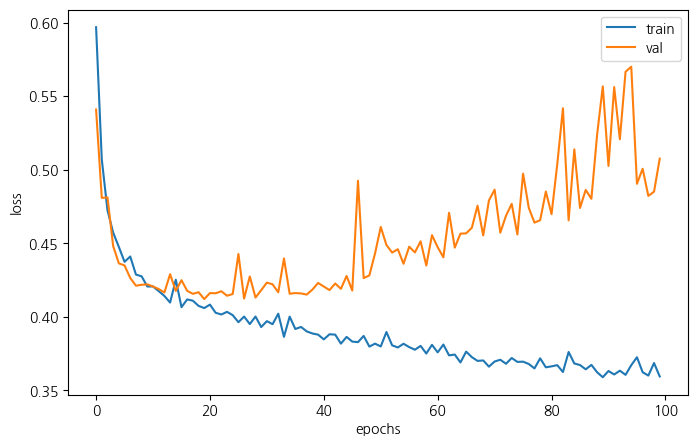

2026-03-18 11:36:26.135144: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-18 11:36:26.980462: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_20', 100 bytes spill stores, 100 bytes spill loads



9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       165
           1       0.78      0.69      0.73       103

    accuracy                           0.81       268
   macro avg       0.80      0.78      0.79       268
weighted avg       0.80      0.81      0.80       268



In [63]:
# 모델의 파라미터 세팅
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(X_train_ppd, y_train, epochs=100, batch_size=16,
                   validation_data=(X_test_ppd, y_test))
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

pred = model.predict(X_test_ppd)
pred
result = pd.DataFrame(dict(y_test=y_test, pred=pred[:,0]))
result['pred'] =  result['pred'].apply(lambda x: 1 if x >= 0.5 else 0)
print(classification_report(result['y_test'], result['pred']))